In [ ]:
import numpy as np, cv2
import matplotlib.pyplot as plt
from tools.tools import *

%load_ext autoreload
%autoreload 2

REAL_BAG_PATH = "/root/stonefish_ros2_ws/sintef_dataset/2024-08-22_14-29-05_data.bag"
SIM_BAG_PATH = "/root/stonefish_ros2_ws/recorded_data/simulation/rosbag2_2025_11_04-14_02_14"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Read Data

In [4]:
real_ping360_data = get_ping360_data("/root/stonefish_ros2_ws/sintef_dataset/2024-08-20_16-34-34_data.bag")
simulated_ping360_data = get_simulated_image_data(bag="/root/stonefish_ros2_ws/recorded_data/simulation/rosbag2_2025_10_24-08_32_44", topic="/ping_360/image")

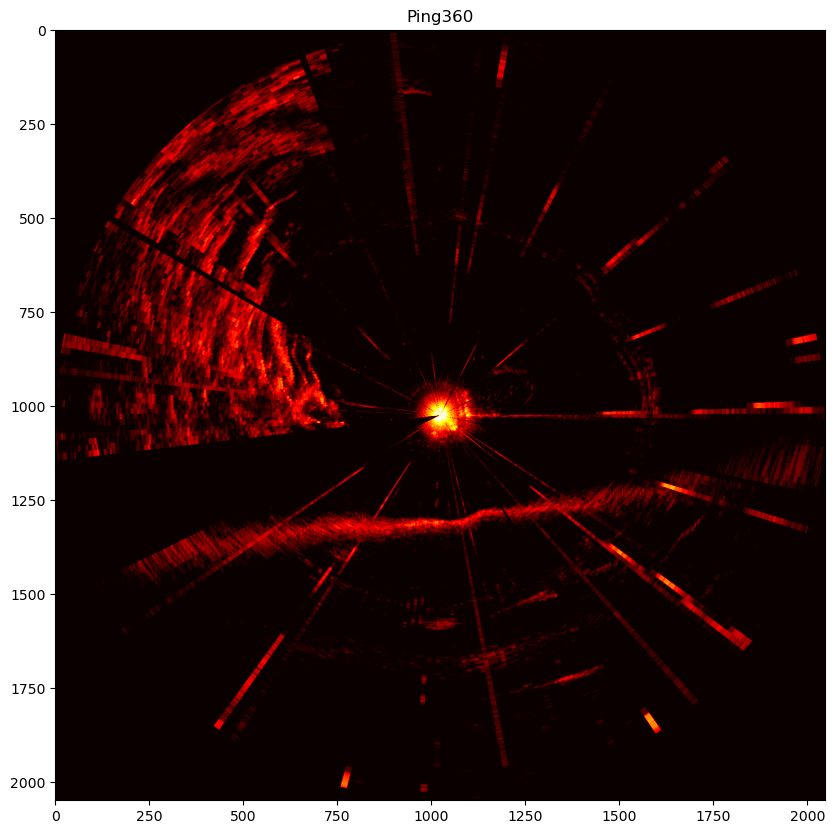

In [5]:
image = get_image_nearest_time(real_ping360_data, 100)

# Map to polar
image = map_to_sector(image, fov_deg=360)

# Normalize intenisty values 0 to 255
image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)

# Log transform
# image = np.log(image + 1)

plt.figure(figsize=(10, 10))
plt.title("Ping360")
plt.imshow(image, cmap="hot")

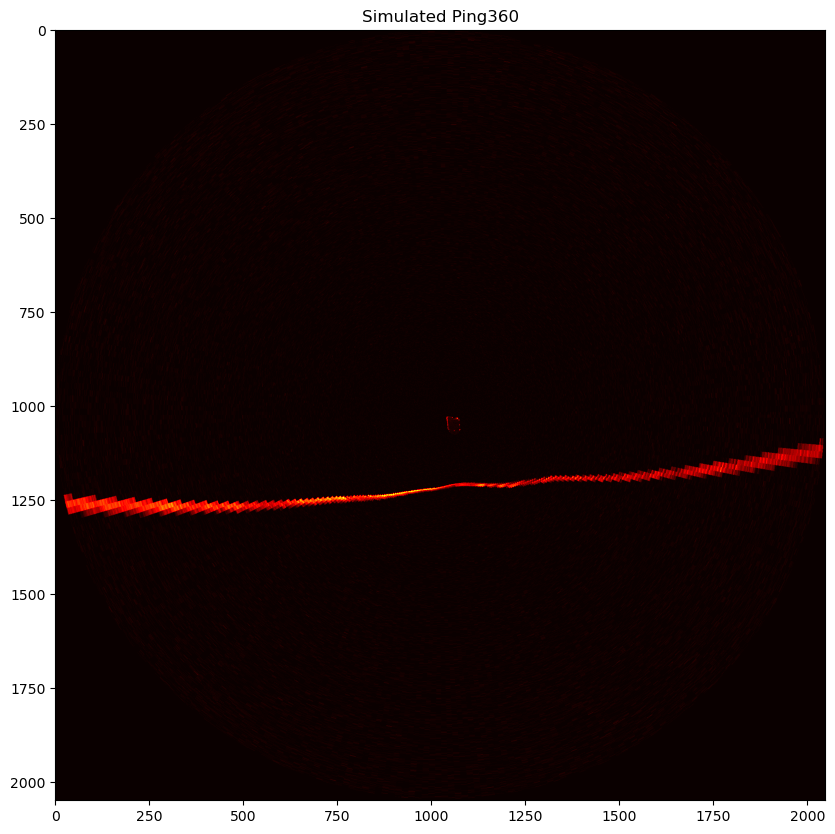

In [4]:
image = get_image_nearest_time(simulated_ping360_data, 100)


# Map to sector (flip first and flip back)
# image = np.flip(image)

image = np.rot90(image, k=2)
image = map_to_sector(image, fov_deg=360)

# Rotate
image = np.rot90(image, k=1)

image = np.fliplr(image)

# Normalize intenisty values 0 to 255
# image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)

# Log transform
# image = np.log(image + 1)

plt.figure(figsize=(10, 10))
plt.title("Simulated Ping360")
plt.imshow(image, cmap="hot")